# Mini Research Problem: SFT+LoRA vs GRPO+LoRA for Local Math Reasoning

This notebook integrates the earlier **SFT LoRA rank-sweep notebook** and the **GRPO + LoRA CPU notebook** into one clean mini-research workflow.

## Study design

We compare:
- **Base model**: `Qwen/Qwen2.5-Math-1.5B`
- **SFT + LoRA** with ranks **8 / 4 / 2**
- **GRPO + LoRA** with rank **2**

The notebook is organized as:
1. setup and benchmark loading
2. prompt and scoring rules
3. metadata and model loading
4. unified evaluation pipeline
5. summary tables
6. one consolidated visuals section
7. future exploration: **LoRA-XS** and **TinyLoRA**


## 1. Motivation and research question

Inspired by **Learning to Reason in 13 Parameters**, this mini research problem asks whether meaningful reasoning gains can be recovered under very small adaptation budgets in a local environment.

### Main questions
1. Can **SFT + LoRA** improve exact-answer math reasoning over the base model?
2. How does **LoRA rank** affect the trade-off between performance and efficiency?
3. How does **GRPO + LoRA (r=2)** compare with **SFT + LoRA (r=2)** under a compact setting?
4. What do these results suggest about plausible next steps such as **LoRA-XS** and **TinyLoRA**?


## 2. Imports and setup

This notebook intentionally supports two loading paths:
- **MLX / mlx-lm** for the SFT LoRA adapters
- **Transformers + PEFT** for the GRPO LoRA checkpoint

That split matches the way the two original notebooks were built.


In [1]:
import os
import re
import json
import math
import random
from typing import Dict, List, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 3. Dataset paths and loading

Update these paths only if your local files use different names.


In [2]:
TRAIN_PATH = "data/train_easy_math_120.jsonl"
VAL_PATH = "data/val_easy_math_30.jsonl"

def load_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

benchmark_100 = load_jsonl('data/benchmark_100.jsonl')
olym_benchmark_100 = load_jsonl('data/olympiad_100_b.jsonl')
aimo_benchmark_150 = load_jsonl('data/aimo_150.jsonl')

print("reasoning_100:", len(benchmark_100))
print("olympiad_100:", len(olym_benchmark_100))
print("aimo_150:", len(aimo_benchmark_150))


reasoning_100: 100
olympiad_100: 100
aimo_150: 150


## 4. Prompt and scoring rules

To keep the comparison fair, all conditions use the same prompt pattern and the same exact-answer extraction rule.


In [3]:
def make_prompt(question: str) -> str:
    return f'''You are a math assistant.
Return only the final numeric answer.
Do not explain.

Examples:
Question: 12 * 13
Answer: 156

Question: 25 + 17
Answer: 42

Question: 84 / 6 + 15
Answer: 29

Now answer:
Question: {question}
Answer:'''

def extract_final_answer(text: str) -> str:
    text = str(text).strip()
    if not text:
        return ""

    first_line = text.splitlines()[0].strip()

    bad_starts = (
        "to solve",
        "to find",
        "we need",
        "the expression",
        "the problem",
        "here are",
        "let's",
        "let us",
    )
    if first_line.lower().startswith(bad_starts):
        return ""

    m = re.search(r"\\boxed\{(-?\d+(?:\.\d+)?)\}", first_line)
    if m:
        return m.group(1)

    m = re.search(r"(?:final answer is|answer is|answer:)\s*(-?\d+(?:\.\d+)?)", first_line, flags=re.I)
    if m:
        return m.group(1)

    m = re.search(r"=\s*(-?\d+(?:\.\d+)?)", first_line)
    if m:
        return m.group(1)

    m = re.fullmatch(r"-?\d+(?:\.\d+)?", first_line)
    if m:
        return m.group(0)

    nums = re.findall(r"-?\d+(?:\.\d+)?", first_line)
    return nums[-1] if nums else ""

def normalize_answer(x: Any) -> str:
    return "" if x is None else str(x).strip().replace(",", "")

def is_correct(pred: Any, gold: Any) -> bool:
    return normalize_answer(pred) == normalize_answer(gold)

## 5. Method metadata

The metadata below uses one consistent schema so the results can be merged cleanly.


In [4]:
BASE_METADATA = {
    "condition": "base",
    "training_method": "Base model",
    "rank": None,
    "training_time_sec": 0.0,
    "trainable_params": 0,
    "total_params": 1_544_259_072,
    "trainable_percent": 0.0,
    "adapter_path": None,
}

SFT_METADATA = {
    "lora_r8_300": {
        "condition": "sft_lora_r8_300",
        "training_method": "SFT+LoRA",
        "rank": 8,
        "training_time_sec": 439.34,
        "trainable_params": 9_232_000,
        "total_params": 1_544_259_072,
        "trainable_percent": 9_232_000 / 1_544_259_072 * 100,
        "adapter_path": "adapters/qwen_math_lora_r8_300",
    },
    "lora_r4_300": {
        "condition": "sft_lora_r4_300",
        "training_method": "SFT+LoRA",
        "rank": 4,
        "training_time_sec": 514.17,
        "trainable_params": 4_616_000,
        "total_params": 1_544_259_072,
        "trainable_percent": 4_616_000 / 1_544_259_072 * 100,
        "adapter_path": "adapters/qwen_math_lora_r4_300",
    },
    "lora_r2_300": {
        "condition": "sft_lora_r2_300",
        "training_method": "SFT+LoRA",
        "rank": 2,
        "training_time_sec": 555.20,
        "trainable_params": 2_308_000,
        "total_params": 1_544_259_072,
        "trainable_percent": 2_308_000 / 1_544_259_072 * 100,
        "adapter_path": "adapters/qwen_math_lora_r2_300",
    },
}

GRPO_METADATA = {
    "grpo_lora_r2_cpu": {
        "condition": "grpo_lora_r2_cpu",
        "training_method": "GRPO+LoRA",
        "rank": 2,
        "training_time_sec": 30838.75,
        "trainable_params": 272_384,
        "total_params": 1_544_259_072,
        "trainable_percent": 272_384 / 1_544_259_072 * 100,
        "adapter_path": "grpo_lora_qwen15b_math_cpu_out/checkpoint-120",
    }
}
pd.concat([
    pd.DataFrame([BASE_METADATA]),
    pd.DataFrame(SFT_METADATA).T.reset_index(drop=True),
    pd.DataFrame(GRPO_METADATA).T.reset_index(drop=True)
], ignore_index=True)

,condition,training_method,rank,training_time_sec,trainable_params,total_params,trainable_percent,adapter_path
0,base,Base model,None,0.0,0,1544259072,0.0,None
1,sft_lora_r8_300,SFT+LoRA,8,439.34,9232000,1544259072,0.597827,adapters/qwen_math_lora_r8_300
2,sft_lora_r4_300,SFT+LoRA,4,514.17,4616000,1544259072,0.298914,adapters/qwen_math_lora_r4_300
3,sft_lora_r2_300,SFT+LoRA,2,555.2,2308000,1544259072,0.149457,adapters/qwen_math_lora_r2_300
4,grpo_lora_r2_cpu,GRPO+LoRA,2,30838.75,272384,1544259072,0.017638,grpo_lora_qwen15b_math_cpu_out/checkpoint-120


## 6. Model loading

Run the loading path that matches your local environment.

### Recommended execution order
1. Run the **SFT MLX loading** cell if your SFT adapters are MLX / mlx-lm adapters.
2. Run the **GRPO transformers + PEFT** cell for the GRPO checkpoint.
3. Then run the smoke tests before the full benchmark evaluation.


In [5]:
from mlx_lm import load, generate

MODEL_NAME = "Qwen/Qwen2.5-Math-1.5B"

base_model_mlx, base_tokenizer_mlx = load(MODEL_NAME)
sft_r8_model, sft_r8_tokenizer = load(MODEL_NAME, adapter_path=SFT_METADATA["lora_r8_300"]["adapter_path"])
sft_r4_model, sft_r4_tokenizer = load(MODEL_NAME, adapter_path=SFT_METADATA["lora_r4_300"]["adapter_path"])
sft_r2_model, sft_r2_tokenizer = load(MODEL_NAME, adapter_path=SFT_METADATA["lora_r2_300"]["adapter_path"])

def run_model_base(question: str) -> str:
    prompt = make_prompt(question)
    response = generate(base_model_mlx, base_tokenizer_mlx, prompt=prompt, max_tokens=20)
    return _postprocess_first_line(response)

def run_model_sft_r8(question: str) -> str:
    prompt = make_prompt(question)
    response = generate(sft_r8_model, sft_r8_tokenizer, prompt=prompt, max_tokens=20)
    return _postprocess_first_line(response)

def run_model_sft_r4(question: str) -> str:
    prompt = make_prompt(question)
    response = generate(sft_r4_model, sft_r4_tokenizer, prompt=prompt, max_tokens=20)
    return _postprocess_first_line(response)

def run_model_sft_r2(question: str) -> str:
    prompt = make_prompt(question)
    response = generate(sft_r2_model, sft_r2_tokenizer, prompt=prompt, max_tokens=20)
    return _postprocess_first_line(response)

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

GRPO_MODEL_NAME = "Qwen/Qwen2.5-Math-1.5B"
grpo_adapter_path = "grpo_lora_qwen15b_math_cpu_out/checkpoint-120"

tokenizer_rl = AutoTokenizer.from_pretrained(GRPO_MODEL_NAME, trust_remote_code=True)
grpo_base_model = AutoModelForCausalLM.from_pretrained(GRPO_MODEL_NAME, trust_remote_code=True)
rl_model = PeftModel.from_pretrained(grpo_base_model, grpo_adapter_path)

def _decode_transformers_first_line(model, tokenizer, prompt: str, max_new_tokens: int = 20) -> str:
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_text = full_text[len(prompt):].strip() if full_text.startswith(prompt) else full_text
    return _postprocess_first_line(generated_text)

def run_model_grpo_r2(question: str) -> str:
    prompt = make_prompt(question)
    return _decode_transformers_first_line(rl_model, tokenizer_rl, prompt, max_new_tokens=20)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [7]:
def _postprocess_first_line(text: str) -> str:
    text = "" if text is None else str(text).replace("<END>", "").strip()
    if not text:
        return ""

    lines = [line.strip() for line in text.splitlines() if line.strip()]

    for line in lines:
        if line not in {"_", "__", "___", "____", "-----"}:
            return line

    return lines[0] if lines else ""

### Optional fallback

If you already defined `run_model_base`, `run_model_sft_r8`, `run_model_sft_r4`, `run_model_sft_r2`, and `run_model_grpo_r2` earlier in your environment, you can skip the loading cells and use them directly.


In [8]:
required_runner_names = [
    "run_model_base",
    "run_model_sft_r8",
    "run_model_sft_r4",
    "run_model_sft_r2",
    "run_model_grpo_r2",
]

missing = [name for name in required_runner_names if name not in globals()]
print("Missing runners:" if missing else "All runners found.", missing)


All runners found. []


## 7. Quick smoke tests

Run this before full evaluation to confirm that each path returns a short answer string.


In [9]:
sample_q = benchmark_100[0]["question"]
print("Question:", sample_q)
print("Base:", run_model_base(sample_q))
print("SFT r8:", run_model_sft_r8(sample_q))
print("SFT r4:", run_model_sft_r4(sample_q))
print("SFT r2:", run_model_sft_r2(sample_q))
print("GRPO r2:", run_model_grpo_r2(sample_q))

Question: 15 + 11
Base: 26
SFT r8: 26
SFT r4: 26
SFT r2: 26
GRPO r2: 26


In [10]:
def preview_runner_outputs(question: str):
    rows = []

    for name, fn in [
        ("base", run_model_base),
        ("sft_r8", run_model_sft_r8),
        ("sft_r4", run_model_sft_r4),
        ("sft_r2", run_model_sft_r2),
        ("grpo_r2", run_model_grpo_r2),
    ]:
        raw = fn(question)
        pred = extract_final_answer(raw)
        rows.append({
            "runner": name,
            "raw_first_line": raw,
            "extracted_answer": pred,
            "word_len": len(str(raw).split()),
        })

    return pd.DataFrame(rows)

# Example:
preview_runner_outputs(benchmark_100[0]["question"])

,runner,raw_first_line,extracted_answer,word_len
0,base,26,26,1
1,sft_r8,26,26,1
2,sft_r4,26,26,1
3,sft_r2,26,26,1
4,grpo_r2,26,26,1


In [11]:
def preview_full_outputs(question: str):
    for name, fn in [
        ("base", run_model_base),
        ("sft_r8", run_model_sft_r8),
        ("sft_r4", run_model_sft_r4),
        ("sft_r2", run_model_sft_r2),
        ("grpo_r2", run_model_grpo_r2),
    ]:
        print(f"\n===== {name} =====")
        out = fn(question)
        print(repr(out))
        print(out)

## 8. Unified evaluation pipeline

All methods are evaluated with the same multi-run exact-answer protocol.


In [12]:
def evaluate_dataset_multi_run(data, runner, n_runs=3, runner_name="model"):
    rows = []

    for ex in data:
        outputs = []
        preds = []
        lengths = []

        for _ in range(n_runs):
            raw = runner(ex["question"])
            raw = "" if raw is None else str(raw).strip()
            pred = extract_final_answer(raw)

            outputs.append(raw)
            preds.append(pred)
            lengths.append(len(raw.split()))

        majority_pred = pd.Series(preds).value_counts().index[0] if len(preds) else ""
        majority_correct = is_correct(majority_pred, ex["answer"])
        consistency = len(set(preds)) == 1 if len(preds) else False

        rows.append({
            "id": ex.get("id", ""),
            "difficulty": ex.get("difficulty", "unknown"),
            "topic": ex.get("topic", "unknown"),
            "question": ex["question"],
            "gold": normalize_answer(ex["answer"]),

            "raw_output_1": outputs[0] if len(outputs) > 0 else "",
            "raw_output_2": outputs[1] if len(outputs) > 1 else "",
            "raw_output_3": outputs[2] if len(outputs) > 2 else "",

            "pred_1": preds[0] if len(preds) > 0 else "",
            "pred_2": preds[1] if len(preds) > 1 else "",
            "pred_3": preds[2] if len(preds) > 2 else "",

            "correct_1": is_correct(preds[0], ex["answer"]) if len(preds) > 0 else False,
            "correct_2": is_correct(preds[1], ex["answer"]) if len(preds) > 1 else False,
            "correct_3": is_correct(preds[2], ex["answer"]) if len(preds) > 2 else False,

            "majority_pred": majority_pred,
            "majority_correct": majority_correct,
            "avg_approx_token_len": float(np.mean(lengths)) if lengths else 0.0,
            "consistent_across_3_runs": consistency,
            "runner_name": runner_name,
        })

    return pd.DataFrame(rows)

def summarize_metrics(
    df,
    condition_name,
    benchmark_name,
    training_method,
    rank,
    training_time_sec,
    trainable_params,
    total_params,
    trainable_percent,
    base_accuracy=None,
):
    final_answer_accuracy = df["majority_correct"].mean()
    avg_token_length = df["avg_approx_token_len"].mean()
    consistency_rate = df["consistent_across_3_runs"].mean()

    accuracy_gain = np.nan
    relative_gain_pct = np.nan
    improvement_per_parameter = np.nan
    accuracy_gain_per_1k_params = np.nan
    accuracy_gain_per_1m_params = np.nan
    accuracy_per_hour = np.nan

    if base_accuracy is not None:
        accuracy_gain = final_answer_accuracy - base_accuracy
        if base_accuracy > 0:
            relative_gain_pct = (accuracy_gain / base_accuracy) * 100

    if trainable_params and trainable_params > 0 and not pd.isna(accuracy_gain):
        improvement_per_parameter = accuracy_gain / trainable_params
        accuracy_gain_per_1k_params = accuracy_gain / (trainable_params / 1_000)
        accuracy_gain_per_1m_params = accuracy_gain / (trainable_params / 1_000_000)

    if training_time_sec and training_time_sec > 0:
        accuracy_per_hour = final_answer_accuracy / (training_time_sec / 3600)

    return {
        "benchmark": benchmark_name,
        "condition": condition_name,
        "training_method": training_method,
        "rank": rank,
        "final_answer_accuracy": final_answer_accuracy,
        "avg_token_length": avg_token_length,
        "consistency_across_3_runs": consistency_rate,
        "training_time_sec": training_time_sec,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "trainable_percent": trainable_percent,
        "accuracy_gain": accuracy_gain,
        "relative_gain_pct": relative_gain_pct,
        "improvement_per_parameter": improvement_per_parameter,
        "accuracy_gain_per_1k_params": accuracy_gain_per_1k_params,
        "accuracy_gain_per_1m_params": accuracy_gain_per_1m_params,
        "accuracy_per_hour": accuracy_per_hour,
    }

def round_summary_table(df):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].round(6)
    return df

In [13]:
def benchmark_summary_sft(name, dataset):
    df_base = evaluate_dataset_multi_run(dataset, run_model_base, n_runs=3, runner_name="base")
    df_r8 = evaluate_dataset_multi_run(dataset, run_model_sft_r8, n_runs=3, runner_name="sft_r8")
    df_r4 = evaluate_dataset_multi_run(dataset, run_model_sft_r4, n_runs=3, runner_name="sft_r4")
    df_r2 = evaluate_dataset_multi_run(dataset, run_model_sft_r2, n_runs=3, runner_name="sft_r2")

    base_acc = df_base["majority_correct"].mean()

    summary = pd.DataFrame([
        summarize_metrics(
            df_base, "base", name,
            BASE_METADATA["training_method"], BASE_METADATA["rank"],
            BASE_METADATA["training_time_sec"], BASE_METADATA["trainable_params"],
            BASE_METADATA["total_params"], BASE_METADATA["trainable_percent"],
            base_accuracy=None,
        ),
        summarize_metrics(
            df_r8, SFT_METADATA["lora_r8_300"]["condition"], name,
            SFT_METADATA["lora_r8_300"]["training_method"], SFT_METADATA["lora_r8_300"]["rank"],
            SFT_METADATA["lora_r8_300"]["training_time_sec"], SFT_METADATA["lora_r8_300"]["trainable_params"],
            SFT_METADATA["lora_r8_300"]["total_params"], SFT_METADATA["lora_r8_300"]["trainable_percent"],
            base_accuracy=base_acc,
        ),
        summarize_metrics(
            df_r4, SFT_METADATA["lora_r4_300"]["condition"], name,
            SFT_METADATA["lora_r4_300"]["training_method"], SFT_METADATA["lora_r4_300"]["rank"],
            SFT_METADATA["lora_r4_300"]["training_time_sec"], SFT_METADATA["lora_r4_300"]["trainable_params"],
            SFT_METADATA["lora_r4_300"]["total_params"], SFT_METADATA["lora_r4_300"]["trainable_percent"],
            base_accuracy=base_acc,
        ),
        summarize_metrics(
            df_r2, SFT_METADATA["lora_r2_300"]["condition"], name,
            SFT_METADATA["lora_r2_300"]["training_method"], SFT_METADATA["lora_r2_300"]["rank"],
            SFT_METADATA["lora_r2_300"]["training_time_sec"], SFT_METADATA["lora_r2_300"]["trainable_params"],
            SFT_METADATA["lora_r2_300"]["total_params"], SFT_METADATA["lora_r2_300"]["trainable_percent"],
            base_accuracy=base_acc,
        ),
    ])

    return df_base, df_r8, df_r4, df_r2, round_summary_table(summary)

def benchmark_summary_grpo(name, dataset):
    df_base = evaluate_dataset_multi_run(dataset, run_model_base, n_runs=3, runner_name="base")
    df_grpo_r2 = evaluate_dataset_multi_run(dataset, run_model_grpo_r2, n_runs=3, runner_name="grpo_r2")

    base_acc = df_base["majority_correct"].mean()

    summary = pd.DataFrame([
        summarize_metrics(
            df_base, "base", name,
            BASE_METADATA["training_method"], BASE_METADATA["rank"],
            BASE_METADATA["training_time_sec"], BASE_METADATA["trainable_params"],
            BASE_METADATA["total_params"], BASE_METADATA["trainable_percent"],
            base_accuracy=None,
        ),
        summarize_metrics(
            df_grpo_r2, GRPO_METADATA["grpo_lora_r2_cpu"]["condition"], name,
            GRPO_METADATA["grpo_lora_r2_cpu"]["training_method"], GRPO_METADATA["grpo_lora_r2_cpu"]["rank"],
            GRPO_METADATA["grpo_lora_r2_cpu"]["training_time_sec"], GRPO_METADATA["grpo_lora_r2_cpu"]["trainable_params"],
            GRPO_METADATA["grpo_lora_r2_cpu"]["total_params"], GRPO_METADATA["grpo_lora_r2_cpu"]["trainable_percent"],
            base_accuracy=base_acc,
        ),
    ])

    return df_base, df_grpo_r2, round_summary_table(summary)

## 9. Run model-based benchmark evaluations

These cells compute the results directly from the loaded models. There are no hard-coded observed result rows in this version.


In [14]:
df_reason_100_base, df_reason_100_r8, df_reason_100_r4, df_reason_100_r2, summary_100_b_reason = benchmark_summary_sft(
    "reasoning_100", benchmark_100 
)

df_oly_100_b_base, df_oly_100_b_r8, df_oly_100_b_r4, df_oly_100_b_r2, summary_100_b_oly = benchmark_summary_sft(
    "olympiad_100", olym_benchmark_100
)

df_aimo_150_base, df_aimo_150_r8, df_aimo_150_r4, df_aimo_150_r2, summary_100_b_aimo = benchmark_summary_sft(
    "aimo_150", aimo_benchmark_150
)

all_summaries_sft = pd.concat(
    [summary_100_b_reason, summary_100_b_oly, summary_100_b_aimo],
    ignore_index=True
)
all_summaries_sft = round_summary_table(all_summaries_sft)
all_summaries_sft

,benchmark,condition,training_method,rank,final_answer_accuracy,avg_token_length,consistency_across_3_runs,training_time_sec,trainable_params,total_params,trainable_percent,accuracy_gain,relative_gain_pct,improvement_per_parameter,accuracy_gain_per_1k_params,accuracy_gain_per_1m_params,accuracy_per_hour
0,reasoning_100,base,Base model,NaN,0.860000,1.1,1.0,0.00,0,1544259072,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,reasoning_100,sft_lora_r8_300,SFT+LoRA,8.0,0.870000,1.0,1.0,439.34,9232000,1544259072,0.597827,0.010000,1.162791,0.0,0.000001,0.001083,7.128875
2,reasoning_100,sft_lora_r4_300,SFT+LoRA,4.0,0.870000,1.0,1.0,514.17,4616000,1544259072,0.298914,0.010000,1.162791,0.0,0.000002,0.002166,6.091371
3,reasoning_100,sft_lora_r2_300,SFT+LoRA,2.0,0.880000,1.0,1.0,555.20,2308000,1544259072,0.149457,0.020000,2.325581,0.0,0.000009,0.008666,5.706052
4,olympiad_100,base,Base model,NaN,0.570000,1.0,1.0,0.00,0,1544259072,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
5,olympiad_100,sft_lora_r8_300,SFT+LoRA,8.0,0.580000,1.0,1.0,439.34,9232000,1544259072,0.597827,0.010000,1.754386,0.0,0.000001,0.001083,4.752583
6,olympiad_100,sft_lora_r4_300,SFT+LoRA,4.0,0.590000,1.0,1.0,514.17,4616000,1544259072,0.298914,0.020000,3.508772,0.0,0.000004,0.004333,4.130929
7,olympiad_100,sft_lora_r2_300,SFT+LoRA,2.0,0.590000,1.0,1.0,555.20,2308000,1544259072,0.149457,0.020000,3.508772,0.0,0.000009,0.008666,3.825648
8,aimo_150,base,Base model,NaN,0.706667,1.1,1.0,0.00,0,1544259072,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
9,aimo_150,sft_lora_r8_300,SFT+LoRA,8.0,0.726667,1.0,1.0,439.34,9232000,1544259072,0.597827,0.020000,2.830189,0.0,0.000002,0.002166,5.954386


In [15]:
df_reason_100_grpo_base,  df_reason_100_grpo_r2, summary_100_grpo_reason = benchmark_summary_grpo(
    "reasoning_100", benchmark_100 
)

df_oly_100_b_grpo_base,  df_oly_100_b_grpo_r2, summary_100_grpo_oly = benchmark_summary_grpo(
    "olympiad_100", olym_benchmark_100
)

df_aimo_150_grpo_base, df_aimo_150_grpo_r2, summary_100_grpo_aimo = benchmark_summary_grpo(
    "aimo_150", aimo_benchmark_150
)

all_summaries_grpo = pd.concat(
    [summary_100_grpo_reason, summary_100_grpo_oly, summary_100_grpo_aimo],
    ignore_index=True
)
all_summaries_grpo = round_summary_table(all_summaries_grpo)
all_summaries_grpo

,benchmark,condition,training_method,rank,final_answer_accuracy,avg_token_length,consistency_across_3_runs,training_time_sec,trainable_params,total_params,trainable_percent,accuracy_gain,relative_gain_pct,improvement_per_parameter,accuracy_gain_per_1k_params,accuracy_gain_per_1m_params,accuracy_per_hour
0,reasoning_100,base,Base model,NaN,0.860000,1.100000,1.0,0.00,0,1544259072,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,reasoning_100,grpo_lora_r2_cpu,GRPO+LoRA,2.0,0.860000,1.100000,1.0,30838.75,272384,1544259072,0.017638,0.00,0.000000,0.0,0.000000,0.000000,0.100393
2,olympiad_100,base,Base model,NaN,0.570000,1.000000,1.0,0.00,0,1544259072,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,olympiad_100,grpo_lora_r2_cpu,GRPO+LoRA,2.0,0.580000,1.000000,1.0,30838.75,272384,1544259072,0.017638,0.01,1.754386,0.0,0.000037,0.036713,0.067707
4,aimo_150,base,Base model,NaN,0.706667,1.100000,1.0,0.00,0,1544259072,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
5,aimo_150,grpo_lora_r2_cpu,GRPO+LoRA,2.0,0.706667,1.113333,1.0,30838.75,272384,1544259072,0.017638,0.00,0.000000,0.0,0.000000,0.000000,0.082494


In [16]:
all_compare = pd.concat([all_summaries_sft, all_summaries_grpo], ignore_index=True)

def pretty_condition_name(x):
    mapping = {
        "base": "Base",
        "sft_lora_r8_300": "SFT LoRA r=8",
        "sft_lora_r4_300": "SFT LoRA r=4",
        "sft_lora_r2_300": "SFT LoRA r=2",
        "grpo_lora_r2_cpu": "GRPO LoRA r=2",
    }
    return mapping.get(x, x)

all_compare["condition_pretty"] = all_compare["condition"].map(pretty_condition_name)

# remove duplicate benchmark-condition rows
all_compare = (
    all_compare
    .groupby(
        ["benchmark", "condition", "condition_pretty", "training_method", "rank"],
        as_index=False
    )
    .agg({
        "final_answer_accuracy": "mean",
        "avg_token_length": "mean",
        "consistency_across_3_runs": "mean",
        "training_time_sec": "mean",
        "trainable_params": "mean",
        "total_params": "mean",
        "trainable_percent": "mean",
        "accuracy_gain": "mean",
        "relative_gain_pct": "mean",
        "improvement_per_parameter": "mean",
        "accuracy_gain_per_1k_params": "mean",
        "accuracy_gain_per_1m_params": "mean",
        "accuracy_per_hour": "mean",
    })
)

all_compare = round_summary_table(all_compare)
all_compare

,benchmark,condition,condition_pretty,training_method,rank,final_answer_accuracy,avg_token_length,consistency_across_3_runs,training_time_sec,trainable_params,total_params,trainable_percent,accuracy_gain,relative_gain_pct,improvement_per_parameter,accuracy_gain_per_1k_params,accuracy_gain_per_1m_params,accuracy_per_hour
0,aimo_150,grpo_lora_r2_cpu,GRPO LoRA r=2,GRPO+LoRA,2.0,0.706667,1.113333,1.0,30838.75,272384.0,1.544259e+09,0.017638,0.000000,0.000000,0.0,0.000000,0.000000,0.082494
1,aimo_150,sft_lora_r2_300,SFT LoRA r=2,SFT+LoRA,2.0,0.726667,1.000000,1.0,555.20,2308000.0,1.544259e+09,0.149457,0.020000,2.830189,0.0,0.000009,0.008666,4.711816
2,aimo_150,sft_lora_r4_300,SFT LoRA r=4,SFT+LoRA,4.0,0.733333,1.000000,1.0,514.17,4616000.0,1.544259e+09,0.298914,0.026667,3.773585,0.0,0.000006,0.005777,5.134489
3,aimo_150,sft_lora_r8_300,SFT LoRA r=8,SFT+LoRA,8.0,0.726667,1.000000,1.0,439.34,9232000.0,1.544259e+09,0.597827,0.020000,2.830189,0.0,0.000002,0.002166,5.954386
4,olympiad_100,grpo_lora_r2_cpu,GRPO LoRA r=2,GRPO+LoRA,2.0,0.580000,1.000000,1.0,30838.75,272384.0,1.544259e+09,0.017638,0.010000,1.754386,0.0,0.000037,0.036713,0.067707
5,olympiad_100,sft_lora_r2_300,SFT LoRA r=2,SFT+LoRA,2.0,0.590000,1.000000,1.0,555.20,2308000.0,1.544259e+09,0.149457,0.020000,3.508772,0.0,0.000009,0.008666,3.825648
6,olympiad_100,sft_lora_r4_300,SFT LoRA r=4,SFT+LoRA,4.0,0.590000,1.000000,1.0,514.17,4616000.0,1.544259e+09,0.298914,0.020000,3.508772,0.0,0.000004,0.004333,4.130929
7,olympiad_100,sft_lora_r8_300,SFT LoRA r=8,SFT+LoRA,8.0,0.580000,1.000000,1.0,439.34,9232000.0,1.544259e+09,0.597827,0.010000,1.754386,0.0,0.000001,0.001083,4.752583
8,reasoning_100,grpo_lora_r2_cpu,GRPO LoRA r=2,GRPO+LoRA,2.0,0.860000,1.100000,1.0,30838.75,272384.0,1.544259e+09,0.017638,0.000000,0.000000,0.0,0.000000,0.000000,0.100393
9,reasoning_100,sft_lora_r2_300,SFT LoRA r=2,SFT+LoRA,2.0,0.880000,1.000000,1.0,555.20,2308000.0,1.544259e+09,0.149457,0.020000,2.325581,0.0,0.000009,0.008666,5.706052


## 10. Consolidated tables


In [17]:
ranking_table = all_compare.sort_values(
    ["benchmark", "final_answer_accuracy", "accuracy_gain", "consistency_across_3_runs"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

best_per_benchmark = (
    all_compare.sort_values(["benchmark", "final_answer_accuracy"], ascending=[True, False])
    .groupby("benchmark")
    .head(1)
    .reset_index(drop=True)
)

print("Ranking table:")
display(ranking_table)
print("Best per benchmark:")
display(best_per_benchmark[["benchmark", "condition_pretty", "training_method", "rank", "final_answer_accuracy", "accuracy_gain"]])


Ranking table:


,benchmark,condition,condition_pretty,training_method,rank,final_answer_accuracy,avg_token_length,consistency_across_3_runs,training_time_sec,trainable_params,total_params,trainable_percent,accuracy_gain,relative_gain_pct,improvement_per_parameter,accuracy_gain_per_1k_params,accuracy_gain_per_1m_params,accuracy_per_hour
0,aimo_150,sft_lora_r4_300,SFT LoRA r=4,SFT+LoRA,4.0,0.733333,1.000000,1.0,514.17,4616000.0,1.544259e+09,0.298914,0.026667,3.773585,0.0,0.000006,0.005777,5.134489
1,aimo_150,sft_lora_r2_300,SFT LoRA r=2,SFT+LoRA,2.0,0.726667,1.000000,1.0,555.20,2308000.0,1.544259e+09,0.149457,0.020000,2.830189,0.0,0.000009,0.008666,4.711816
2,aimo_150,sft_lora_r8_300,SFT LoRA r=8,SFT+LoRA,8.0,0.726667,1.000000,1.0,439.34,9232000.0,1.544259e+09,0.597827,0.020000,2.830189,0.0,0.000002,0.002166,5.954386
3,aimo_150,grpo_lora_r2_cpu,GRPO LoRA r=2,GRPO+LoRA,2.0,0.706667,1.113333,1.0,30838.75,272384.0,1.544259e+09,0.017638,0.000000,0.000000,0.0,0.000000,0.000000,0.082494
4,olympiad_100,sft_lora_r2_300,SFT LoRA r=2,SFT+LoRA,2.0,0.590000,1.000000,1.0,555.20,2308000.0,1.544259e+09,0.149457,0.020000,3.508772,0.0,0.000009,0.008666,3.825648
5,olympiad_100,sft_lora_r4_300,SFT LoRA r=4,SFT+LoRA,4.0,0.590000,1.000000,1.0,514.17,4616000.0,1.544259e+09,0.298914,0.020000,3.508772,0.0,0.000004,0.004333,4.130929
6,olympiad_100,grpo_lora_r2_cpu,GRPO LoRA r=2,GRPO+LoRA,2.0,0.580000,1.000000,1.0,30838.75,272384.0,1.544259e+09,0.017638,0.010000,1.754386,0.0,0.000037,0.036713,0.067707
7,olympiad_100,sft_lora_r8_300,SFT LoRA r=8,SFT+LoRA,8.0,0.580000,1.000000,1.0,439.34,9232000.0,1.544259e+09,0.597827,0.010000,1.754386,0.0,0.000001,0.001083,4.752583
8,reasoning_100,sft_lora_r2_300,SFT LoRA r=2,SFT+LoRA,2.0,0.880000,1.000000,1.0,555.20,2308000.0,1.544259e+09,0.149457,0.020000,2.325581,0.0,0.000009,0.008666,5.706052
9,reasoning_100,sft_lora_r4_300,SFT LoRA r=4,SFT+LoRA,4.0,0.870000,1.000000,1.0,514.17,4616000.0,1.544259e+09,0.298914,0.010000,1.162791,0.0,0.000002,0.002166,6.091371


Best per benchmark:


,benchmark,condition_pretty,training_method,rank,final_answer_accuracy,accuracy_gain
0,aimo_150,SFT LoRA r=4,SFT+LoRA,4.0,0.733333,0.026667
1,olympiad_100,SFT LoRA r=2,SFT+LoRA,2.0,0.590000,0.020000
2,reasoning_100,SFT LoRA r=2,SFT+LoRA,2.0,0.880000,0.020000


## 11. Consolidated visuals

All visualizations are grouped here instead of being spread throughout the notebook. This makes the notebook easier to present and easier to export to slides.


In [18]:
def plot_bar_metric_by_benchmark(df, metric, title, ylabel):
    plot_df = df.copy()

    # collapse duplicates like duplicated Base rows after concat
    plot_df = (
        plot_df.groupby(["benchmark", "condition_pretty"], as_index=False)[metric]
        .mean()
    )

    benchmarks = list(plot_df["benchmark"].drop_duplicates())
    conditions = list(plot_df["condition_pretty"].drop_duplicates())

    x = np.arange(len(benchmarks))
    width = 0.18

    plt.figure(figsize=(10, 5))

    for i, cond in enumerate(conditions):
        sub = (
            plot_df[plot_df["condition_pretty"] == cond]
            .set_index("benchmark")
            .reindex(benchmarks)
        )

        xpos = x + i * width - width * (len(conditions) - 1) / 2
        plt.bar(xpos, sub[metric].values, width=width, label=cond)

    plt.xticks(x, benchmarks)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_single_benchmark_bars(df: pd.DataFrame, benchmark_name: str, metric: str, title: str, ylabel: str):
    sub = df[df["benchmark"] == benchmark_name].copy()
    sub = sub.sort_values(["training_method", "rank"], na_position="first")

    plt.figure(figsize=(9, 4.5))
    plt.bar(sub["condition_pretty"], sub[metric])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_scatter(df: pd.DataFrame, xcol: str, ycol: str, title: str, xlabel: str, ylabel: str, annotate: bool = True, logx: bool = False):
    plt.figure(figsize=(8, 5))
    plt.scatter(df[xcol], df[ycol])

    if annotate:
        for _, row in df.iterrows():
            plt.annotate(
                row["condition_pretty"] + "" + row["benchmark"],
                (row[xcol], row[ycol]),
                fontsize=8,
                xytext=(4, 4),
                textcoords="offset points",
            )

    if logx:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_heatmap(pivot_df: pd.DataFrame, title: str):
    plt.figure(figsize=(8, 4.5))
    plt.imshow(pivot_df.values, aspect="auto")
    plt.xticks(range(len(pivot_df.columns)), pivot_df.columns, rotation=30, ha="right")
    plt.yticks(range(len(pivot_df.index)), pivot_df.index)
    plt.title(title)
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.iloc[i, j]
            txt = "" if pd.isna(val) else f"{val:.3f}"
            plt.text(j, i, txt, ha="center", va="center", fontsize=8)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


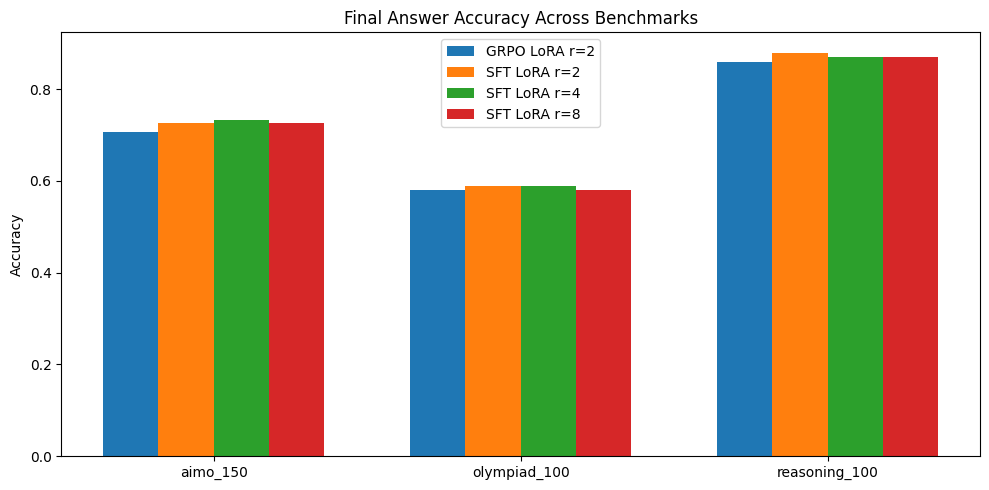

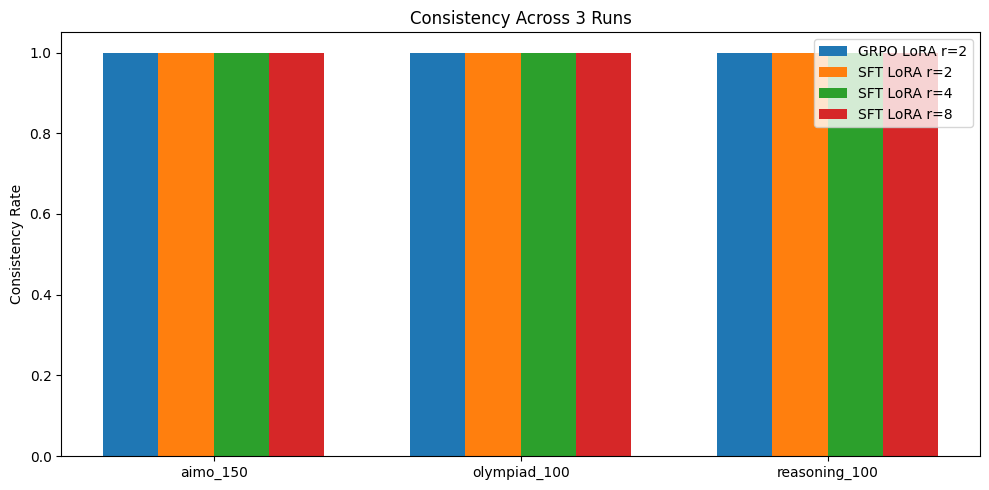

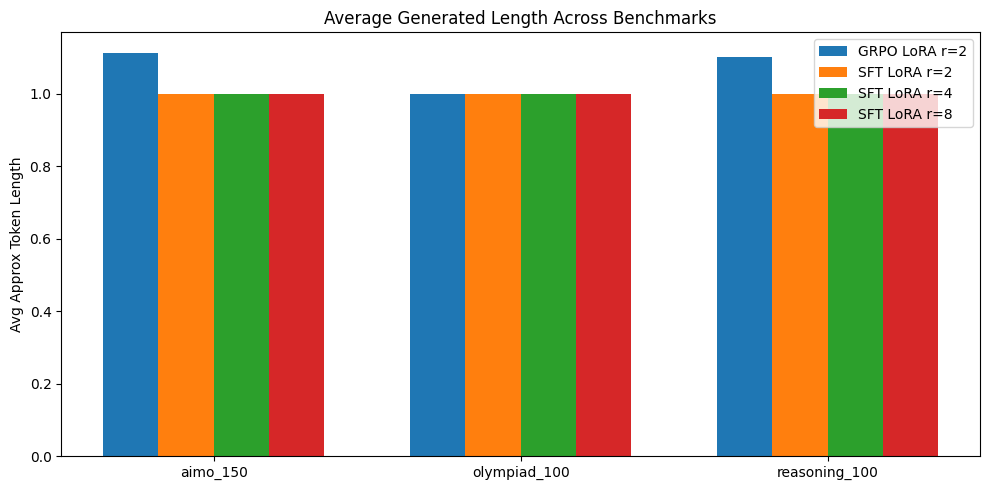

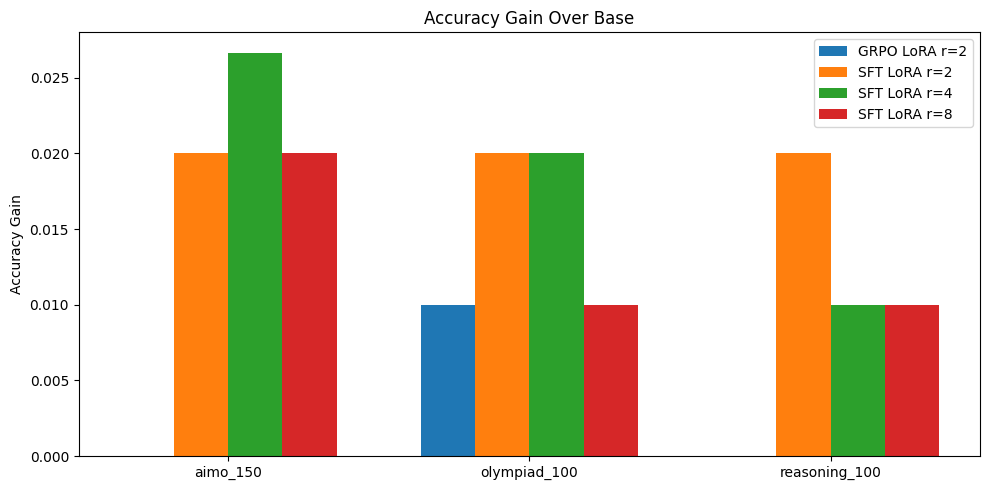

In [19]:
# --- Core comparison charts ---
plot_bar_metric_by_benchmark(all_compare, "final_answer_accuracy", "Final Answer Accuracy Across Benchmarks", "Accuracy")
plot_bar_metric_by_benchmark(all_compare, "consistency_across_3_runs", "Consistency Across 3 Runs", "Consistency Rate")
plot_bar_metric_by_benchmark(all_compare, "avg_token_length", "Average Generated Length Across Benchmarks", "Avg Approx Token Length")
plot_bar_metric_by_benchmark(all_compare[all_compare["condition"] != "base"], "accuracy_gain", "Accuracy Gain Over Base", "Accuracy Gain")


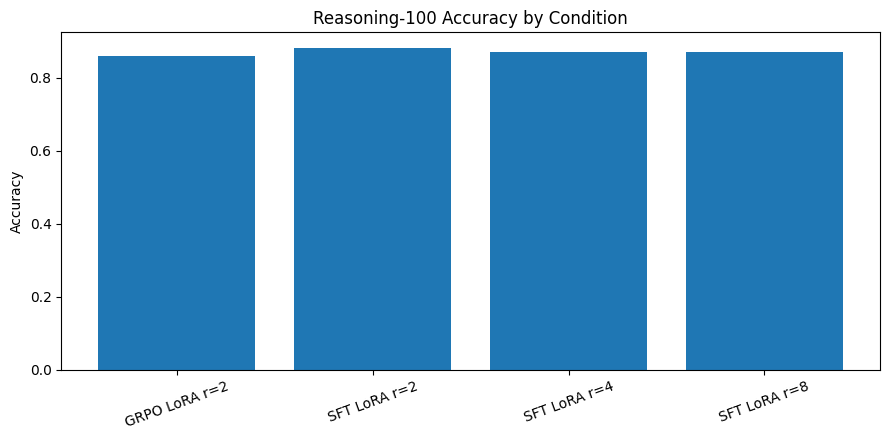

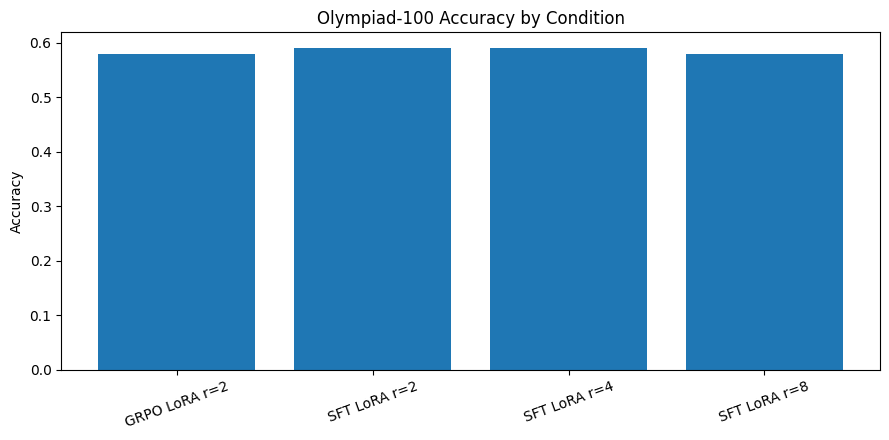

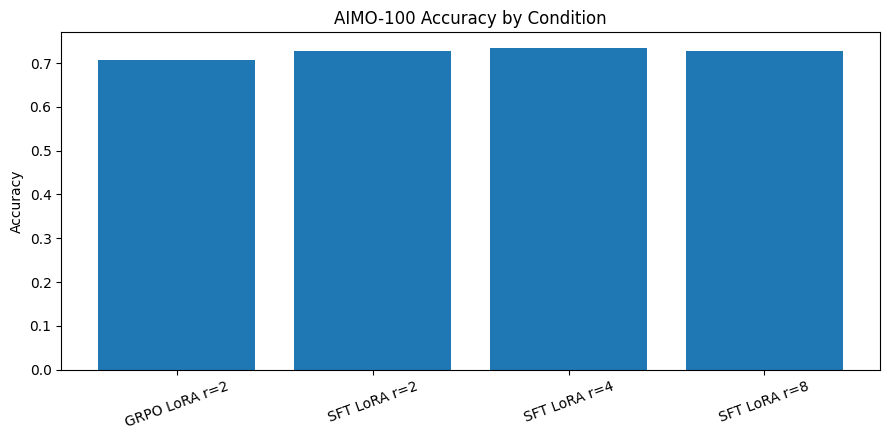

In [20]:
# --- Per-benchmark accuracy views ---
plot_single_benchmark_bars(all_compare, "reasoning_100", "final_answer_accuracy", "Reasoning-100 Accuracy by Condition", "Accuracy")
plot_single_benchmark_bars(all_compare, "olympiad_100", "final_answer_accuracy", "Olympiad-100 Accuracy by Condition", "Accuracy")
plot_single_benchmark_bars(all_compare, "aimo_150", "final_answer_accuracy", "AIMO-100 Accuracy by Condition", "Accuracy")


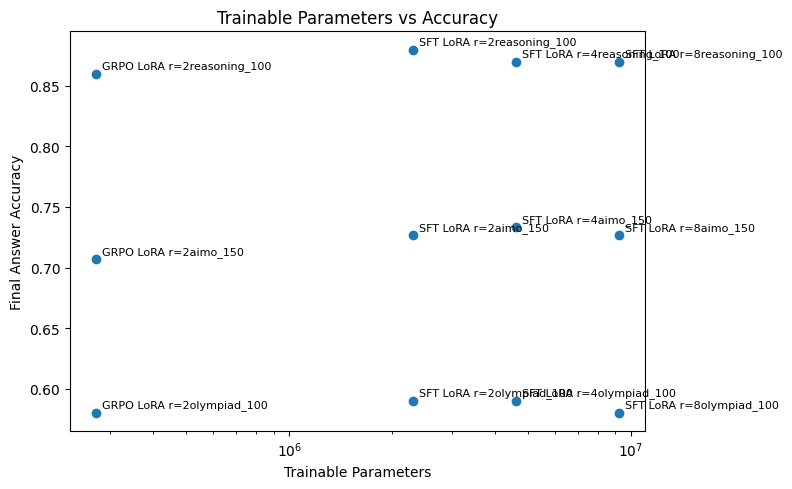

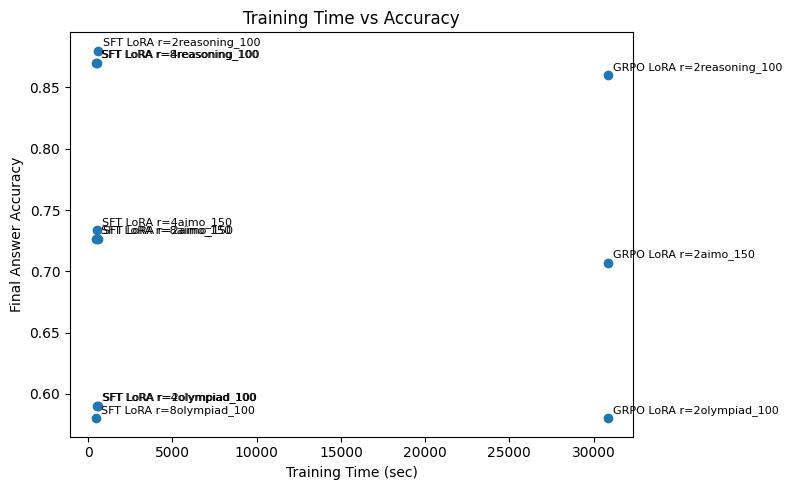

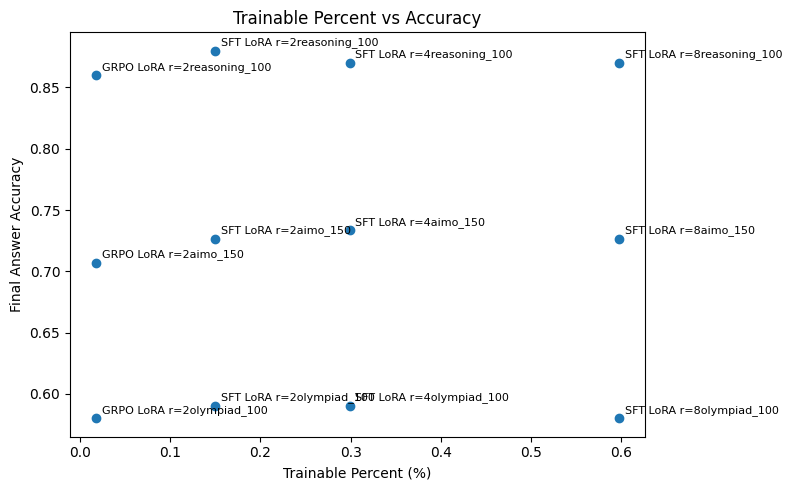

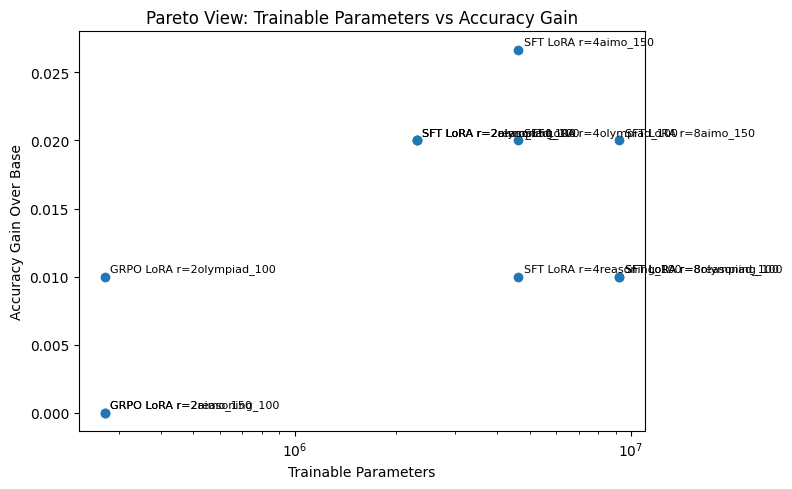

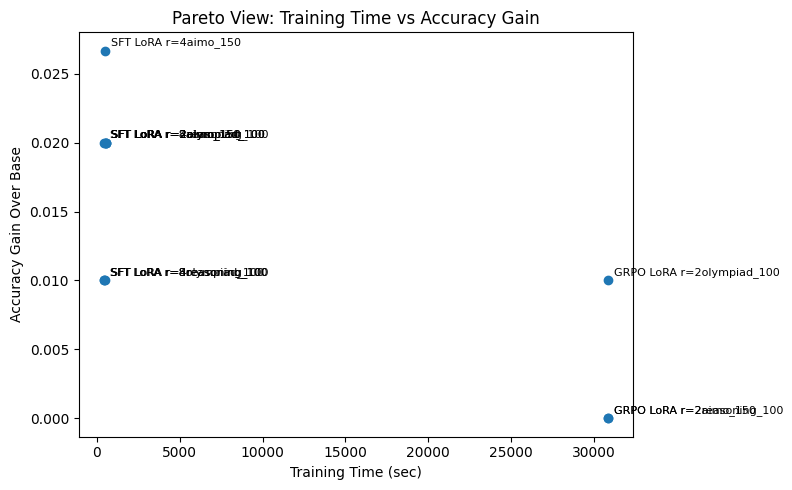

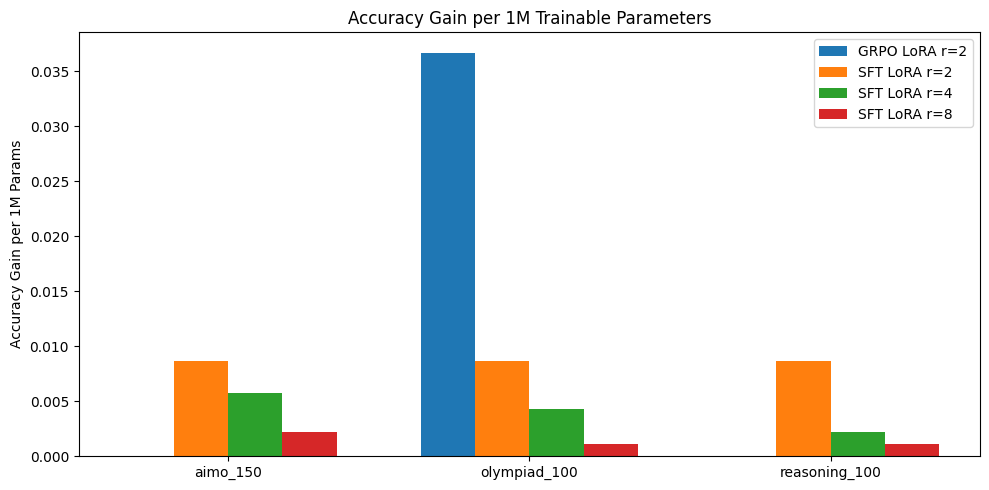

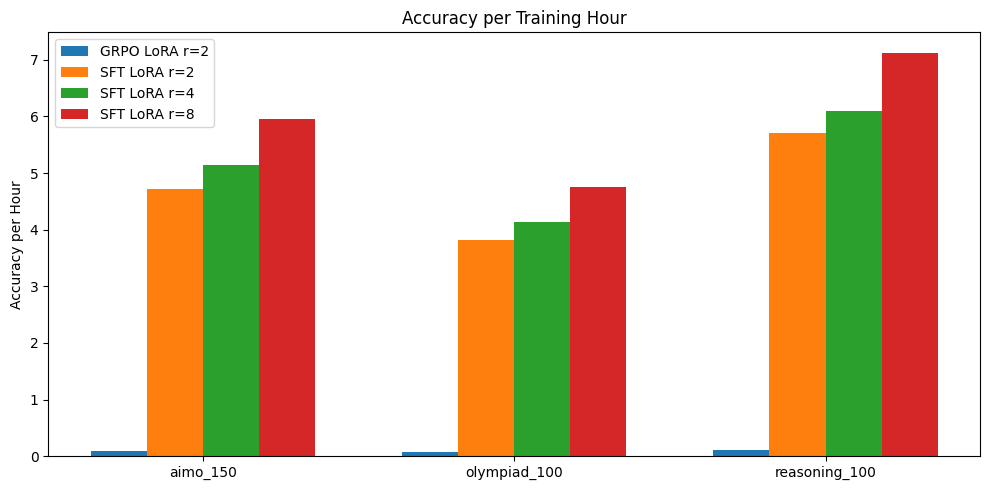

In [21]:
# --- Efficiency and trade-off charts ---
trained_only = all_compare[all_compare["condition"] != "base"].copy()
plot_scatter(trained_only, "trainable_params", "final_answer_accuracy", "Trainable Parameters vs Accuracy", "Trainable Parameters", "Final Answer Accuracy", logx=True)
plot_scatter(trained_only, "training_time_sec", "final_answer_accuracy", "Training Time vs Accuracy", "Training Time (sec)", "Final Answer Accuracy")
plot_scatter(trained_only, "trainable_percent", "final_answer_accuracy", "Trainable Percent vs Accuracy", "Trainable Percent (%)", "Final Answer Accuracy")
plot_scatter(trained_only, "trainable_params", "accuracy_gain", "Pareto View: Trainable Parameters vs Accuracy Gain", "Trainable Parameters", "Accuracy Gain Over Base", logx=True)
plot_scatter(trained_only, "training_time_sec", "accuracy_gain", "Pareto View: Training Time vs Accuracy Gain", "Training Time (sec)", "Accuracy Gain Over Base")
plot_bar_metric_by_benchmark(trained_only, "accuracy_gain_per_1m_params", "Accuracy Gain per 1M Trainable Parameters", "Accuracy Gain per 1M Params")
plot_bar_metric_by_benchmark(trained_only, "accuracy_per_hour", "Accuracy per Training Hour", "Accuracy per Hour")


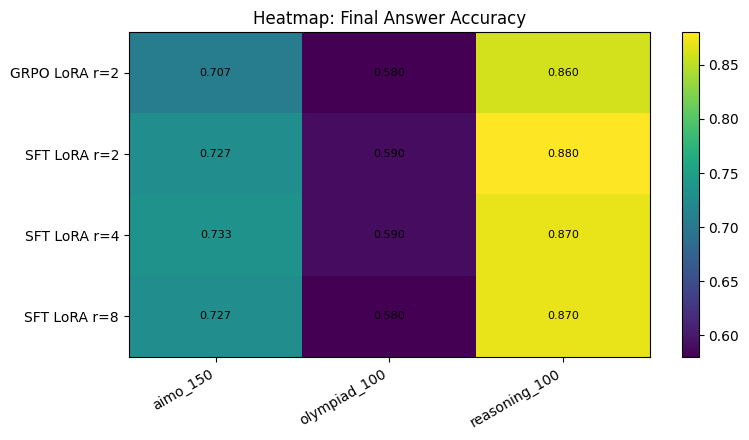

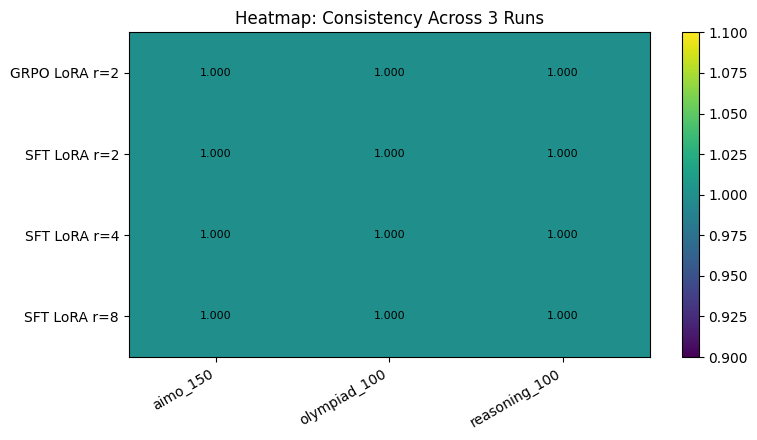

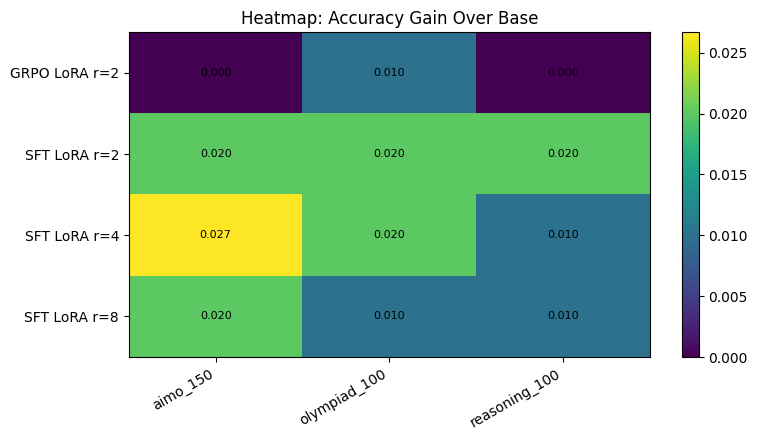

In [22]:
# --- Heatmaps ---
pivot_acc = all_compare.pivot(index="condition_pretty", columns="benchmark", values="final_answer_accuracy")
pivot_consistency = all_compare.pivot(index="condition_pretty", columns="benchmark", values="consistency_across_3_runs")
pivot_gain = all_compare[all_compare["condition"] != "base"].pivot(index="condition_pretty", columns="benchmark", values="accuracy_gain")

plot_heatmap(pivot_acc, "Heatmap: Final Answer Accuracy")
plot_heatmap(pivot_consistency, "Heatmap: Consistency Across 3 Runs")
plot_heatmap(pivot_gain, "Heatmap: Accuracy Gain Over Base")


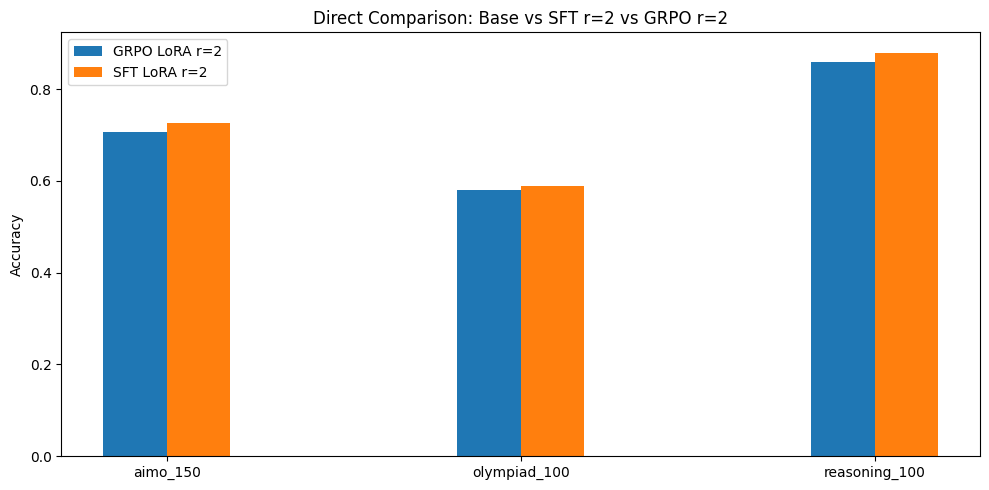

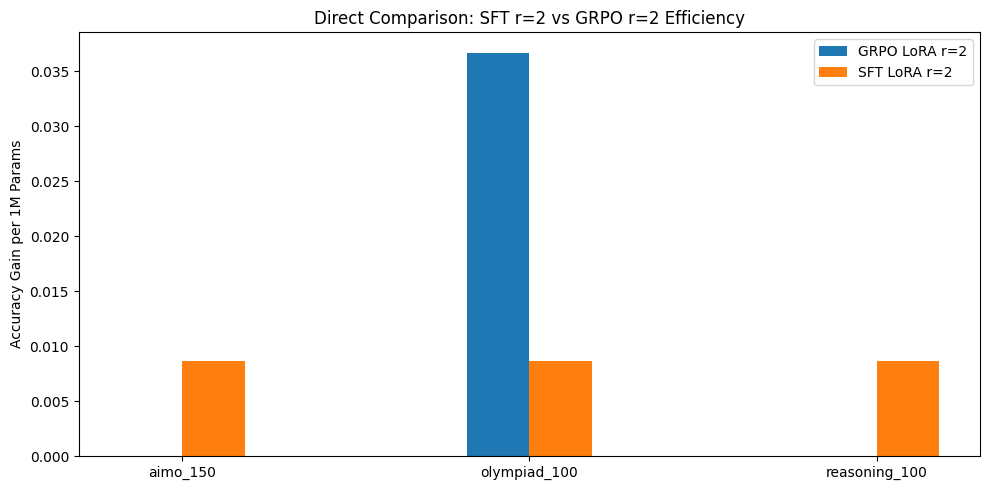

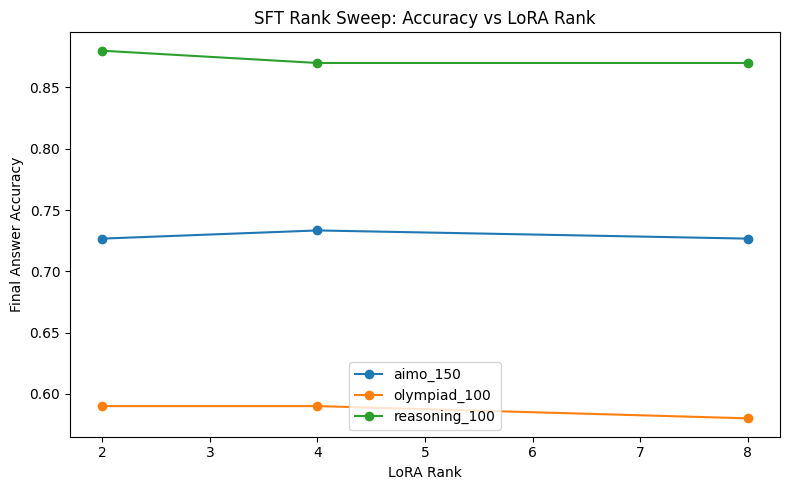

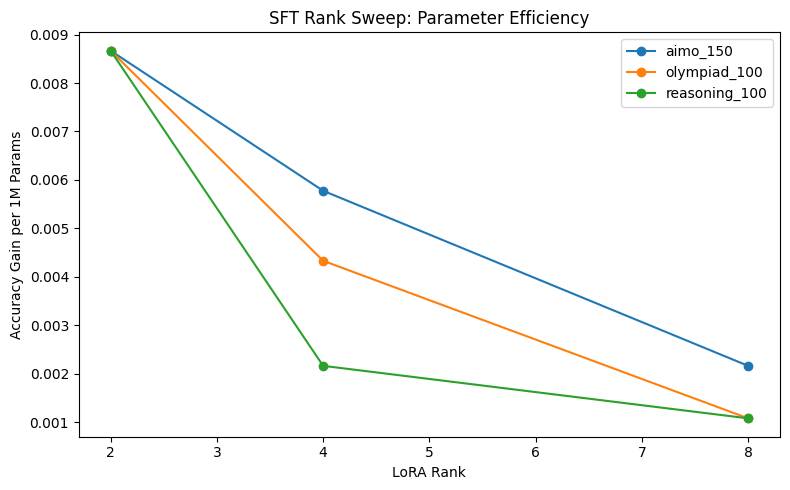

In [23]:
# --- Direct r=2 comparison and SFT rank sweep ---
r2_compare = all_compare[all_compare["condition"].isin(["base", "sft_lora_r2_300", "grpo_lora_r2_cpu"])].copy()
plot_bar_metric_by_benchmark(r2_compare, "final_answer_accuracy", "Direct Comparison: Base vs SFT r=2 vs GRPO r=2", "Accuracy")
plot_bar_metric_by_benchmark(r2_compare[r2_compare["condition"] != "base"], "accuracy_gain_per_1m_params", "Direct Comparison: SFT r=2 vs GRPO r=2 Efficiency", "Accuracy Gain per 1M Params")

sft_only = all_compare[all_compare["training_method"] == "SFT+LoRA"].copy()
plt.figure(figsize=(8, 5))
for benchmark in sft_only["benchmark"].unique():
    sub = sft_only[sft_only["benchmark"] == benchmark].sort_values("rank")
    plt.plot(sub["rank"], sub["final_answer_accuracy"], marker="o", label=benchmark)
plt.xlabel("LoRA Rank")
plt.ylabel("Final Answer Accuracy")
plt.title("SFT Rank Sweep: Accuracy vs LoRA Rank")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for benchmark in sft_only["benchmark"].unique():
    sub = sft_only[sft_only["benchmark"] == benchmark].sort_values("rank")
    plt.plot(sub["rank"], sub["accuracy_gain_per_1m_params"], marker="o", label=benchmark)
plt.xlabel("LoRA Rank")
plt.ylabel("Accuracy Gain per 1M Params")
plt.title("SFT Rank Sweep: Parameter Efficiency")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Optional detailed analysis from per-example outputs

These helpers let you inspect topic, difficulty, and qualitative mistakes after the main benchmark runs finish.


In [24]:
def summarize_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    if df is None or len(df) == 0 or group_col not in df.columns:
        return pd.DataFrame()
    out = (
        df.groupby(group_col)
        .agg(
            accuracy=("majority_correct", "mean"),
            consistency=("consistent_across_3_runs", "mean"),
            avg_len=("avg_approx_token_len", "mean"),
            n=("id", "count"),
        )
        .reset_index()
        .sort_values("accuracy", ascending=False)
    )
    return out


def show_wrong_details(df: pd.DataFrame, max_rows: int = 8) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()
    cols = [
        "id", "topic", "difficulty", "question", "gold",
        "majority_pred", "majority_correct",
        "raw_output_1", "raw_output_2", "raw_output_3",
    ]
    cols = [c for c in cols if c in df.columns]
    return df[df["majority_correct"] == False][cols].head(max_rows)


## 13. Future exploration: LoRA-XS and TinyLoRA

These are kept as future work rather than fake completed results.


In [25]:
future_exploration = pd.DataFrame([
    {
        "method": "LoRA-XS",
        "status": "planned",
        "motivation": "Push trainable parameter count lower than standard LoRA while preserving reasoning gains.",
        "expected_tradeoff": "Much smaller adapters, possible drop in final accuracy, stronger parameter efficiency.",
    },
    {
        "method": "TinyLoRA",
        "status": "planned",
        "motivation": "Explore ultra-compact adaptation inspired by learning-to-reason-with-extreme-parameter budgets.",
        "expected_tradeoff": "Very low trainable parameter count, likely harder optimization, but strong research value.",
    },
])

future_exploration


,method,status,motivation,expected_tradeoff
0,LoRA-XS,planned,Push trainable parameter count lower than stan...,"Much smaller adapters, possible drop in final ..."
1,TinyLoRA,planned,Explore ultra-compact adaptation inspired by l...,"Very low trainable parameter count, likely har..."


## 14. Export helpers


In [26]:
os.makedirs("mrp_outputs", exist_ok=True)
all_summaries_sft.to_csv("mrp_outputs/all_summaries_sft.csv", index=False)
all_summaries_grpo.to_csv("mrp_outputs/all_summaries_grpo.csv", index=False)
all_compare.to_csv("mrp_outputs/all_compare.csv", index=False)
ranking_table.to_csv("mrp_outputs/ranking_table.csv", index=False)
best_per_benchmark.to_csv("mrp_outputs/best_per_benchmark.csv", index=False)
future_exploration.to_csv("mrp_outputs/future_exploration.csv", index=False)
print("Saved outputs to mrp_outputs/")
print("Notebook ready. Load the model runners, then execute the evaluation and visuals sections.")


Saved outputs to mrp_outputs/
Notebook ready. Load the model runners, then execute the evaluation and visuals sections.
